# Lab 5 Data Processing Jupyter Notebook
MylaGrace Zapanta

In [11]:
# Import the Necessary Libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from scipy.signal import welch # We'll need this for power spectral density estimation eventually

# Allow for interactive plotting in Jupyter notebooks, comment out the line to turn this off. 
# The % sign is a Jupyter magic command that enables the use of widgets in the notebook.
# This requires installing the ipympl package, so if you get an error on this line, 
# you may need to install it first by running: pip install ipympl

%matplotlib widget 

# For interactive data point selection in plots, this library is useful.
import mplcursors 

# Add this line of code to each plot if you want cursors: 
# mplcursors.cursor(hover=False, multiple=True)  # Enable interactive cursor for data point selection, right-click to remove cursor

# Use this command to set the default font size for your plots.
sns.set_context("notebook")
# Options from smallest to largest: "paper", "notebook", "talk", "poster"

Remember to use both Markdown and Code cells to import and plot your data. Refer back to the Tutorial if you need example code.

## Temperature vs. Time Plot

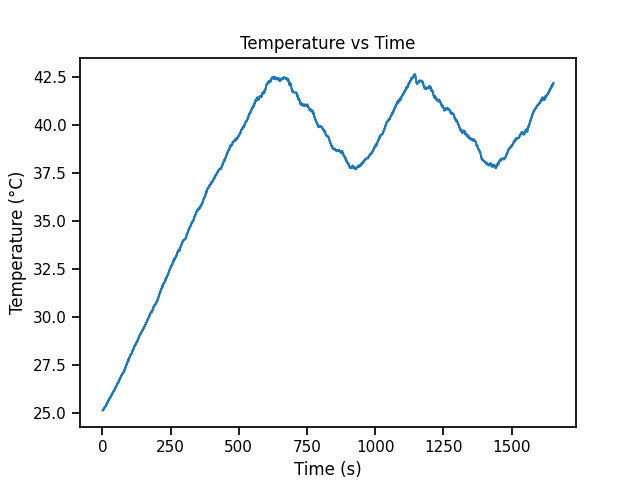

In [52]:
df = pd.read_csv("data1.csv") # Make sure to update this file name to match your data!
df['Time (s)'] = df['Time (ms)'] / 1000  # Convert milliseconds to seconds
df['smoothed'] = df[' Temperature (C)'].rolling(window=5).mean()

plt.figure()  # Create a new figure
sns.lineplot(x="Time (s)", y=" Temperature (C)", data=df)  # Create a line plot of Temperature vs Time
plt.title("Temperature vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

## Current vs. Time Plot

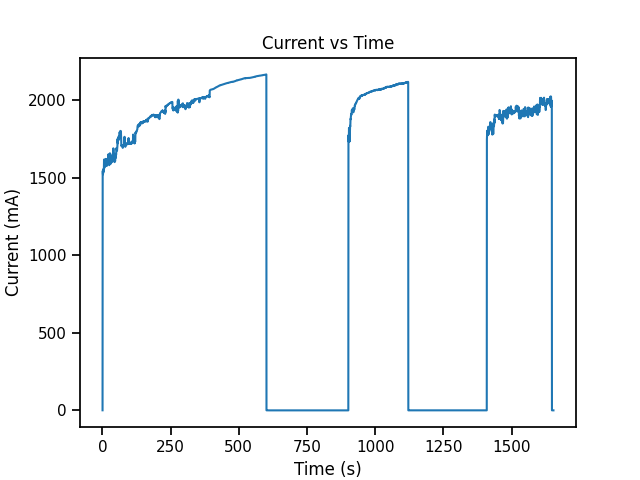

In [13]:
df['smoothed'] = df[' Current (mA)'].rolling(window=5).mean()
df['Time (s)'] = df['Time (ms)'] / 1000  # Convert milliseconds to seconds

plt.figure()  # Create a new figure
sns.lineplot(x="Time (s)", y=" Current (mA)", data=df)  # Create a line plot of Sensor 1 vs Time
plt.title("Current vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Current (mA)")

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

## Power vs. Time Plot

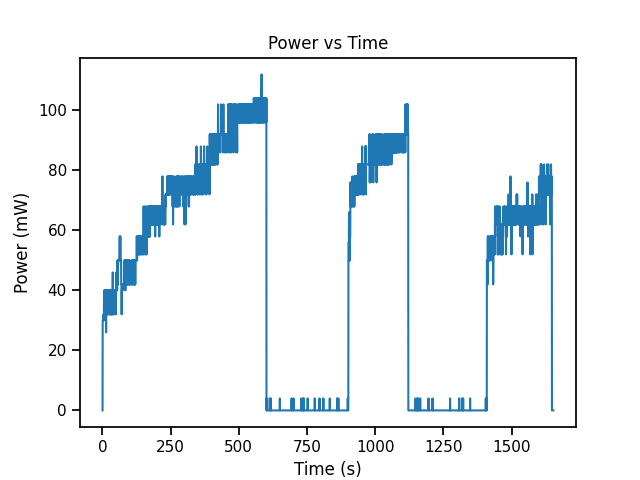

In [53]:
df['smoothed'] = df[' Power (mW)'].rolling(window=5).mean()
df['Time (s)'] = df['Time (ms)'] / 1000  # Convert milliseconds to seconds

plt.figure()  # Create a new figure
sns.lineplot(x="Time (s)", y=" Power (mW)", data=df)  # Create a line plot of Sensor 1 vs Time
plt.title("Power vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Power (mW)")

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

## What is the efficiency of heating the block from room temperature to the set point of 40℃? 

In [54]:
# variables for efficiency calculation
M = 95.5 # mass of the block in grams
C = 0.9 # specific heat capacity of the block in J/g°C
T = 40 - 25 # change in temperature of the block from room temperature to the set point in °C

df['Time (s)'] = df['Time (ms)'] / 1000 # Convert time from milliseconds to seconds for energy calculation
power_W = df[' Power (mW)'] / 1000 # Convert power from milliwatts to watts for energy calculation

# Calculate energy during the heating phase using trapezoidal integration
start_time = df['Time (s)'].iloc[0]  # or when heating begins near 25°C
end_time = df.loc[df[' Temperature (C)'] >= 40, 'Time (s)'].iloc[0]

mask = (df['Time (s)'] >= start_time) & (df['Time (s)'] <= end_time)
energy_heating_J = np.trapz(power_W[mask], df.loc[mask, 'Time (s)'])

# Calculate energy during the heating phase using trapezoidal integration
efficiency = (M * C * T) / energy_heating_J

print(f"Electrical Energy Input: {M * C * T} J")
print(f"Thermal Energy Output: {energy_heating_J} J")
print(f"Efficiency: {efficiency}")

Electrical Energy Input: 1289.25 J
Thermal Energy Output: 35.8465 J
Efficiency: 35.96585440698534


Presenting the data for the lab report
1. Need to show the specific areas on the power and temperature plot that we used for the calculation. 

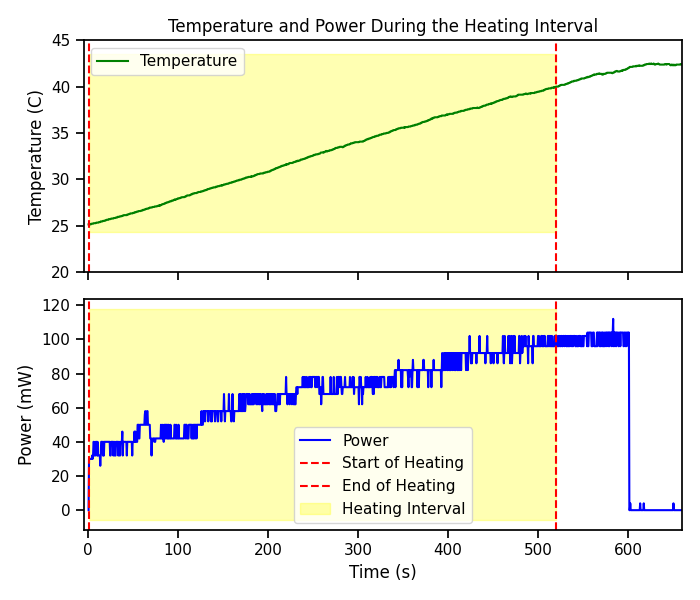

In [32]:
# Define start and end times for the heating phase (from the efficiency calculation)
start_time = df['Time (s)'].iloc[0]  # or when heating begins near 25°C
end_time = df.loc[df[' Temperature (C)'] >= 40, 'Time (s)'].iloc[0]

# Creating sub plots for Temperature and Power
fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=False)

sns.lineplot(x="Time (s)", y=" Temperature (C)", data=df,
              color="green", linestyle="-", label="Temperature", ax=ax[0])
sns.lineplot(x="Time (s)", y=" Power (mW)", data=df,
              color="blue", linestyle="-", label="Power", ax=ax[1])

# Add vertical lines and shading for the heating interval
for a in ax:
    a.axvline(x=start_time, color='red', linestyle='--', label='Start of Heating')
    a.axvline(x=end_time, color='red', linestyle='--', label='End of Heating')
    a.fill_betweenx(y=[a.get_ylim()[0], a.get_ylim()[1]], x1=start_time, x2=end_time, color='yellow', alpha=0.3, label='Heating Interval')

ax[0].set_title("Temperature and Power During the Heating Interval")  # Updated title
ax[0].set_ylim(20, 45)  # Set y-axis limits for temperature plot (20-60 degrees Celsius)
plt.xlabel("Time (s)")  # Set x-label for both plots
ax[0].set_ylabel("Temperature (C)")  # Set y-label for the first plot
ax[1].set_ylabel("Power (mW)")  # Set y-label for the second plot

plt.xlim(-5, 660)  # Set x-axis limits
plt.tight_layout()  # Adjust layout to prevent overlap
plt.legend()  # Add legend to show the lines
plt.show()

## What is the efficiency of heating the block from 38℃ to 42℃ (e.g. where the system will operate most of the time, during the hysteresis loop)?

In [55]:
# variables for efficiency calculation
M = 95.5 # mass of the block in grams
C = 0.9 # specific heat capacity of the block in J/g°C
T = 42-38 # change in temperature of the block in °C

# Store columns into variables
power_W = df[' Power (mW)'] / 1000  # Power in milliwatts
time_s = df['Time (ms)'] / 1000  # Time in seconds

# Mask for temperature between 38°C and 42°C
mask = (df[' Temperature (C)'] >= 38) & (df[' Temperature (C)'] <= 42)

# Calculate energy using trapezoidal integration
energy_J = np.trapz(power_W[mask], time_s[mask])

efficiency = (M * C * T) / energy_J

print(f"Electrical Energy Input: {M * C * T} J")
print(f"Thermal Energy Output: {energy_J} J")
print(f"Efficiency: {efficiency}")

Electrical Energy Input: 343.8 J
Thermal Energy Output: 54.4835 J
Efficiency: 6.310167298356383


Presenting the data for the lab report

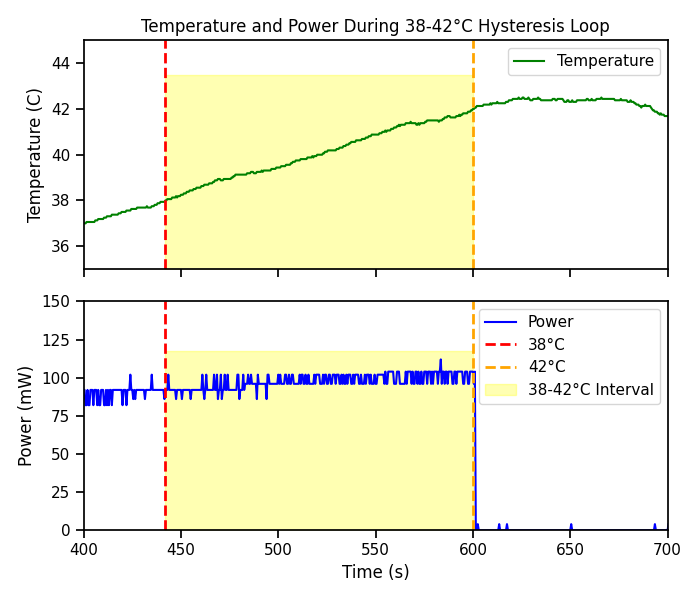

In [31]:
# Define start and end times for the 38-42°C heating phase
# Find first time when temperature reaches 38°C
start_time = df.loc[df[' Temperature (C)'] >= 38, 'Time (s)'].iloc[0]
# Find first time when temperature reaches 42°C
end_time = df.loc[df[' Temperature (C)'] >= 42, 'Time (s)'].iloc[0]

# Creating sub plots for Temperature and Power
fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=False)

sns.lineplot(x="Time (s)", y=" Temperature (C)", data=df,
              color="green", linestyle="-", label="Temperature", ax=ax[0])
sns.lineplot(x="Time (s)", y=" Power (mW)", data=df,
              color="blue", linestyle="-", label="Power", ax=ax[1])

# Add vertical lines and shading for the 38-42°C heating interval
for a in ax:
    a.axvline(x=start_time, color='red', linestyle='--', linewidth=2, label='38°C')
    a.axvline(x=end_time, color='orange', linestyle='--', linewidth=2, label='42°C')
    a.fill_betweenx(y=[a.get_ylim()[0], a.get_ylim()[1]], x1=start_time, x2=end_time, color='yellow', alpha=0.3, label='38-42°C Interval')

ax[0].set_title("Temperature and Power During 38-42°C Hysteresis Loop")
ax[0].set_ylim(35, 45)  # Set y-axis limits for temperature plot
ax[1].set_ylim(0, 150)  # Set y-axis limits for power plot
plt.xlabel("Time (s)")  # Set x-label for both plots
ax[0].set_ylabel("Temperature (C)")  # Set y-label for the first plot
ax[1].set_ylabel("Power (mW)")  # Set y-label for the second plot

plt.xlim(400, 700)  # Adjust x-axis limits as needed
plt.tight_layout()  # Adjust layout to prevent overlap
plt.legend()  # Add legend to show the lines
plt.show()

## What is the average rate of heat loss for the block when the heater turns off at 42℃ until it turns back on at 38℃ ? 

In [33]:
# variables for rate of heat loss calculation
M = 95.5 # mass of the block in grams
C = 0.9 # specific heat capacity of the block in J/g°C
T = 42 - 38 # change in temperature of the block in °C (cooling from 42°C to 38°C)

# Find the time when temperature reaches 42°C (heater turns off)
time_at_42 = df.loc[df[' Temperature (C)'] >= 42, 'Time (s)'].iloc[0]

# Find the time when temperature drops back to 38°C (heater turns back on)
time_at_38 = df.loc[(df[' Temperature (C)'] <= 38) & (df['Time (s)'] > time_at_42), 'Time (s)'].iloc[0]

# Calculate cooling duration
cooling_duration_s = time_at_38 - time_at_42

# Calculate heat loss
heat_loss_J = M * C * T

# Calculate average rate of heat loss
average_heat_loss_rate_W = heat_loss_J / cooling_duration_s

print(f"Cooling duration: {cooling_duration_s:.2f} s")
print(f"Heat loss during cooling: {heat_loss_J:.2f} J")
print(f"Average rate of heat loss: {average_heat_loss_rate_W:.2f} W")

Cooling duration: 298.00 s
Heat loss during cooling: 343.80 J
Average rate of heat loss: 1.15 W


Presenting Data

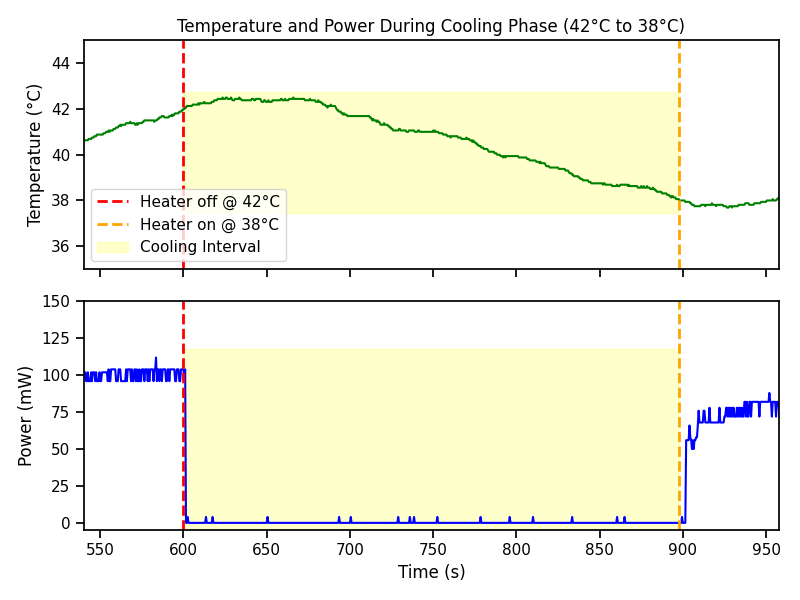

In [42]:
# Define the cooling interval used for the average heat loss calculation
time_at_42 = df.loc[df[' Temperature (C)'] >= 42, 'Time (s)'].iloc[0]
time_at_38 = df.loc[(df[' Temperature (C)'] <= 38) & (df['Time (s)'] > time_at_42), 'Time (s)'].iloc[0]

# Show data before and after the cooling interval
margin = 60  # seconds before and after
plot_start = max(df['Time (s)'].min(), time_at_42 - margin)
plot_end = min(df['Time (s)'].max(), time_at_38 + margin)

plot_mask = (df['Time (s)'] >= plot_start) & (df['Time (s)'] <= plot_end)

# Creating subplots for Temperature and Power
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

sns.lineplot(x="Time (s)", y=" Temperature (C)", data=df[plot_mask], color="green", ax=ax[0])
sns.lineplot(x="Time (s)", y=" Power (mW)", data=df[plot_mask], color="blue", ax=ax[1])

# Add vertical lines and shading for the cooling interval
for a in ax:
    a.axvline(x=time_at_42, color='red', linestyle='--', linewidth=2, label='Heater off @ 42°C')
    a.axvline(x=time_at_38, color='orange', linestyle='--', linewidth=2, label='Heater on @ 38°C')
    a.fill_betweenx([a.get_ylim()[0], a.get_ylim()[1]], x1=time_at_42, x2=time_at_38, 
                     color='yellow', alpha=0.2, label='Cooling Interval' if a == ax[0] else "")

ax[0].set_title("Temperature and Power During Cooling Phase (42°C to 38°C)")
ax[0].set_ylabel("Temperature (°C)")
ax[0].set_ylim(35, 45)
ax[0].legend(loc='lower left')

ax[1].set_ylabel("Power (mW)")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylim(-5, 150)

plt.xlim(plot_start, plot_end)
plt.tight_layout()
plt.show()

## Once the block reaches 40 ℃, how much energy is required to keep the block at constant temperature for 15 minutes? 

In [10]:
# Ensure time is in seconds
df['Time (s)'] = df['Time (ms)'] / 1000

# Power in watts
power_W = df[' Power (mW)'] / 1000

# Find first time when temperature reaches 40°C
start_time = df.loc[df[' Temperature (C)'] >= 40, 'Time (s)'].iloc[0]

# Choose how long after that you want to integrate, e.g. 15 minutes
duration_s = 15 * 60
end_time = start_time + duration_s

# Select the time window
mask = (df['Time (s)'] >= start_time) & (df['Time (s)'] <= end_time)

# Integrate power over that interval
energy_after_40_J = np.trapz(power_W[mask], df.loc[mask, 'Time (s)'])

print(f"Energy used after 40°C for {duration_s} s: {energy_after_40_J:.2f} J")

Energy used after 40°C for 900 s: 27.02 J


Presenting the Data

Energy used after 40°C for 900 s: 27.02 J


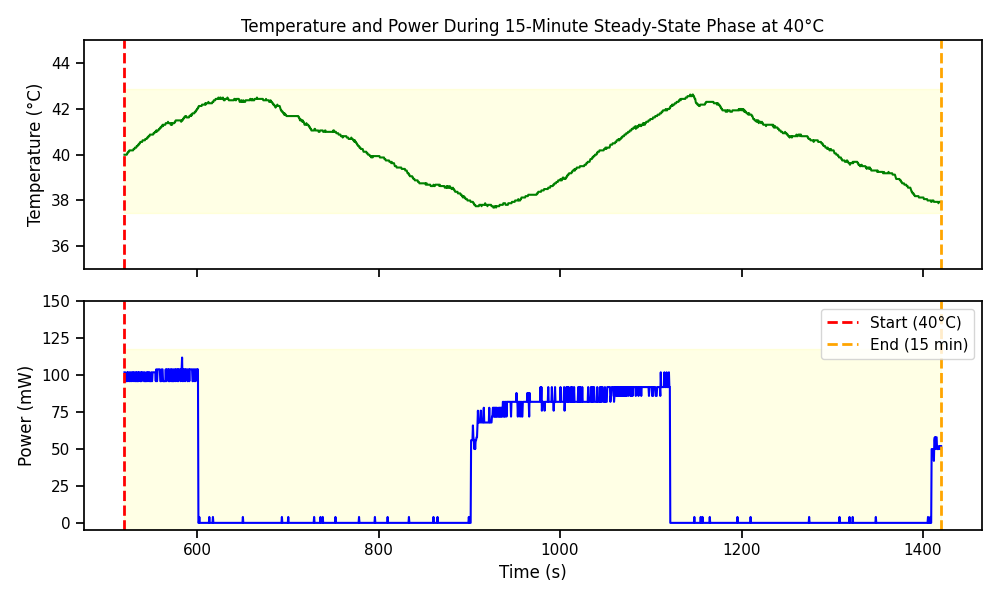

In [47]:
# Ensure time is in seconds
df['Time (s)'] = df['Time (ms)'] / 1000

# Power in watts
power_W = df[' Power (mW)'] / 1000

# Find first time when temperature reaches 40°C
start_time = df.loc[df[' Temperature (C)'] >= 40, 'Time (s)'].iloc[0]

# integration over 15 minutes
duration_s = 15 * 60
end_time = start_time + duration_s

# Time window
mask = (df['Time (s)'] >= start_time) & (df['Time (s)'] <= end_time)

# Integrate power over time window
energy_after_40_J = np.trapz(power_W[mask], df.loc[mask, 'Time (s)'])

print(f"Energy used after 40°C for {duration_s} s: {energy_after_40_J:.2f} J")

# Creating subplots for Temperature and Power during the 15-minute steady-state phase
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

sns.lineplot(x="Time (s)", y=" Temperature (C)", data=df[mask], color="green", ax=ax[0])
sns.lineplot(x="Time (s)", y=" Power (mW)", data=df[mask], color="blue", ax=ax[1])

# Add vertical lines for start and end of the 15-minute interval
for a in ax:
    a.axvline(x=start_time, color='red', linestyle='--', linewidth=2, label='Start (40°C)')
    a.axvline(x=end_time, color='orange', linestyle='--', linewidth=2, label='End (15 min)')
    a.fill_betweenx([a.get_ylim()[0], a.get_ylim()[1]], x1=start_time, x2=end_time,
                     color='yellow', alpha=0.1)

ax[0].set_title("Temperature and Power During 15-Minute Steady-State Phase at 40°C")
ax[0].set_ylabel("Temperature (°C)")
ax[0].set_ylim(35, 45)

ax[1].set_ylabel("Power (mW)")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylim(-5, 150)

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()